# Task 4: Classification Models, Evaluation Metrics & Handling Imbalanced Data

### 1. Importing Necessary Libraries

In [81]:
import pandas as pd              # For data manipulation and analysis
import numpy as np               # For numerical operations
import matplotlib.pyplot as plt  # For data visualization
import seaborn as sns            # For statistical data visualization

from sklearn.datasets import load_breast_cancer                     # For loading the Breast Cancer dataset
from sklearn.model_selection import train_test_split                # For splitting the dataset
from sklearn.preprocessing import StandardScaler                    # For feature scaling
from sklearn.linear_model import LogisticRegression                 # For logistic regression classifier
from sklearn.tree import DecisionTreeClassifier                     # For decision tree classifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)  # For model evaluation metrics

import warnings
warnings.filterwarnings("ignore")  # Suppress warnings for cleaner output

### 2. Loading Dataset

In [82]:
data = load_breast_cancer()                                # Load the Breast Cancer dataset
X = pd.DataFrame(data.data, columns=data.feature_names)    # Features
y = pd.Series(data.target, name="target")                  # Target: 0 = Malignant, 1 = Benign
df = pd.concat([X, y], axis=1)                             # Combine features and target for EDA
display(df.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### 3. Exploratory Data Analysis

In [83]:
print("Dataset shape:", df.shape)

Dataset shape: (569, 31)


In [84]:
print("Missing values in the dataset:", df.isnull().sum().sum())

Missing values in the dataset: 0


In [85]:
# Class distribution to check for imbalance
print("Class distribution (0 = Malignant, 1 = Benign):")
display(y.value_counts())
print("\nClass distribution (%):")
display(y.value_counts(normalize=True) * 100)

Class distribution (0 = Malignant, 1 = Benign):


target
1    357
0    212
Name: count, dtype: int64


Class distribution (%):


target
1    62.741652
0    37.258348
Name: proportion, dtype: float64

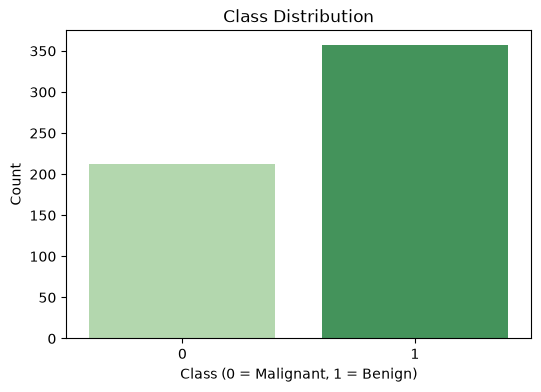

In [86]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette="Greens")
plt.title("Class Distribution")
plt.xlabel("Class (0 = Malignant, 1 = Benign)")
plt.ylabel("Count")
plt.show()

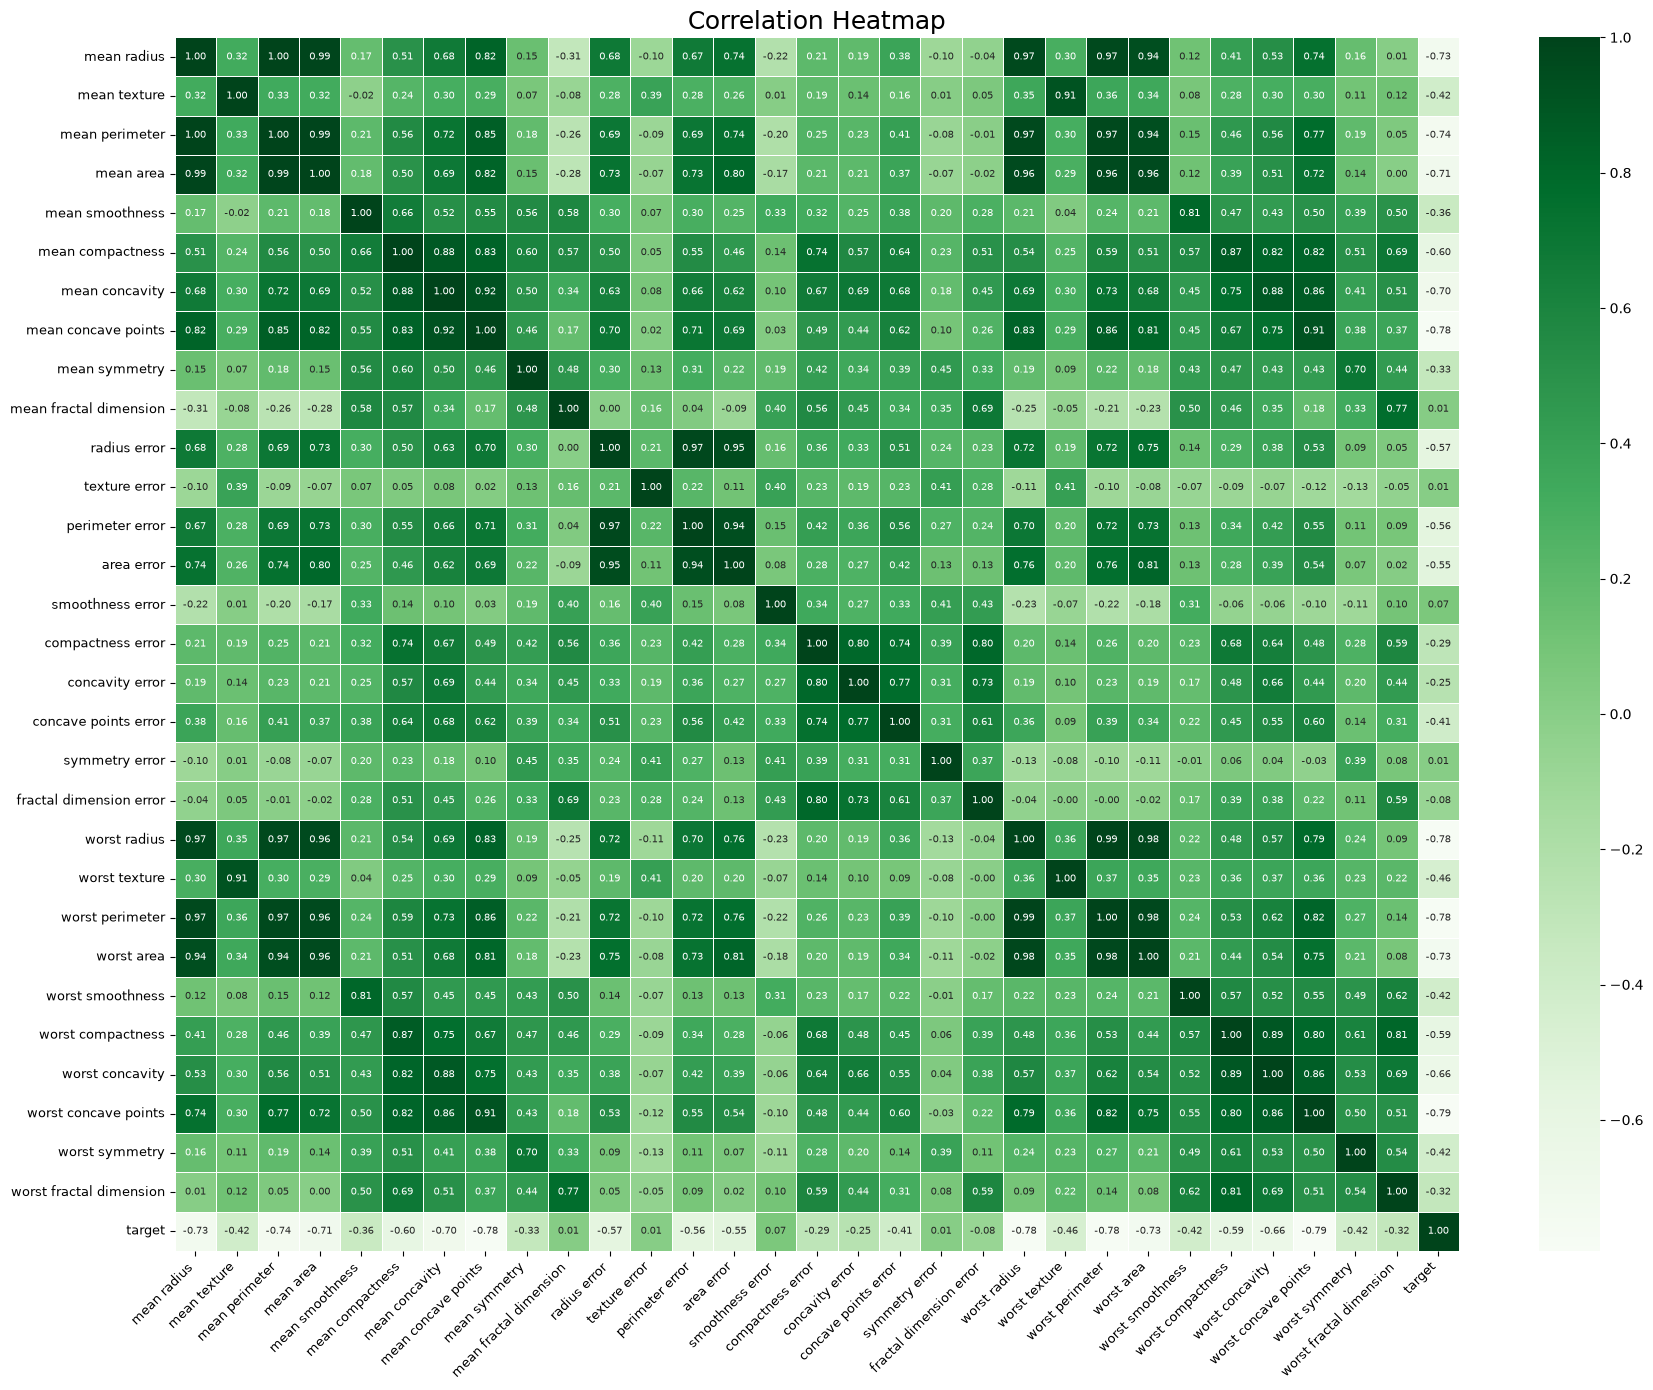

In [87]:
plt.figure(figsize=(18, 14))

corr = df.corr()

sns.heatmap(
    corr,
    cmap="Greens",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 7}
)

plt.title("Correlation Heatmap", fontsize=18)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

### 4. Pre-Processing

In [88]:
# Train-Test split with stratification to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [89]:
# Feature scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 5. Model Training

In [ ]:
# Define all classification models to be trained and evaluated
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Logistic Regression (Balanced)": LogisticRegression(class_weight="balanced", max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

# Train each model and store the trained model, its predictions, and probabilities
trained_models = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)                  # All models trained on scaled features for consistency
    trained_models[name] = {
        "model": model,
        "y_pred": model.predict(X_test_scaled),
        "y_prob": model.predict_proba(X_test_scaled)[:, 1]
    }

print("\nModel training completed.")

Training Logistic Regression...
Training Logistic Regression (Balanced)...
Training Decision Tree...


### 6. Evaluation


Classification Report - Logistic Regression:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Classification Report - Logistic Regression (Balanced):
              precision    recall  f1-score   support

   Malignant       0.91      0.98      0.94        42
      Benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114


Classification Report - Decision Tree:
              precision    recall  f1-score   support

   Malignant       0.85      0.93      0.89        42
      Benign       0.96      0.90      0.93        72

    accuracy                           

,Accuracy,Precision,Recall,F1-Score,AUC
Logistic Regression,0.9825,0.9861,0.9861,0.9861,0.9954
Logistic Regression (Balanced),0.9561,0.9855,0.9444,0.9645,0.9954
Decision Tree,0.9123,0.9559,0.9028,0.9286,0.9157


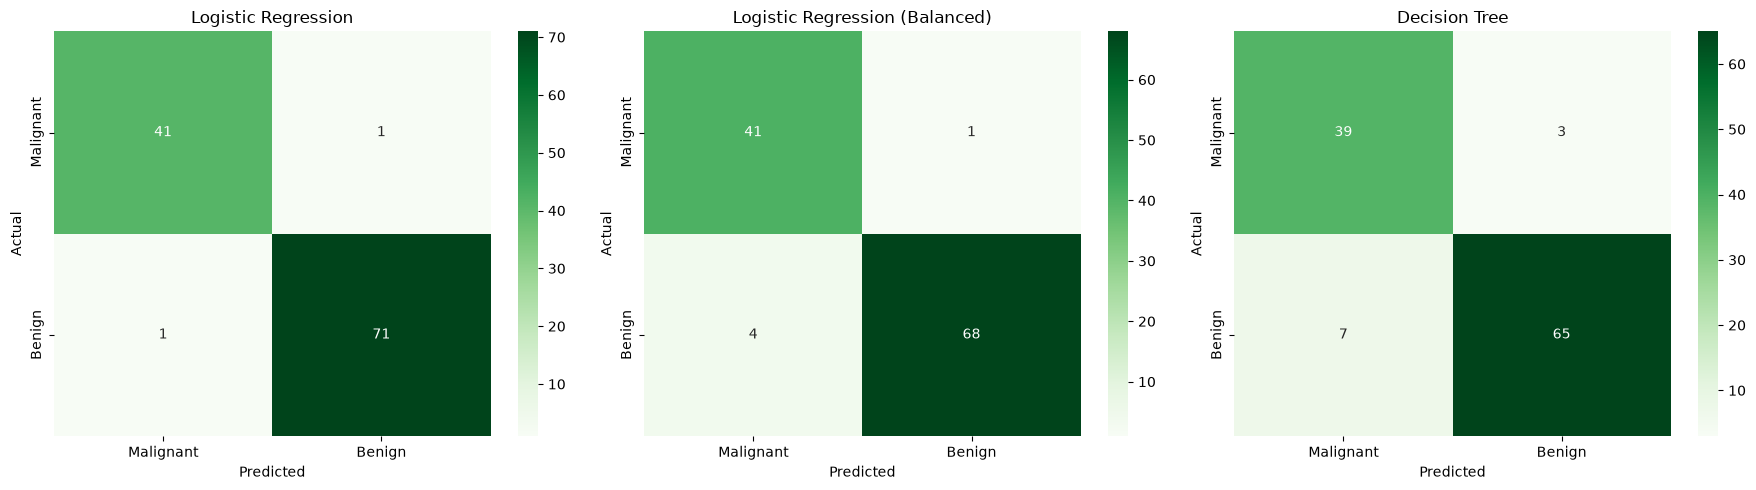

In [91]:
# Evaluate each trained model: metrics table + classification reports + confusion matrix subplots
results = {}
for name, res in trained_models.items():
    y_pred = res["y_pred"]
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, res["y_prob"])
    }
    print(f"\nClassification Report - {name}:")
    print(classification_report(y_test, y_pred, target_names=["Malignant", "Benign"]))

results_df = pd.DataFrame(results).T.round(4).sort_values(by="F1-Score", ascending=False)
print("\nModel Evaluation Results:")
display(results_df)

# Confusion matrices for all models in a single row of subplots
fig, axes = plt.subplots(1, len(trained_models), figsize=(6 * len(trained_models), 5))
for ax, (name, res) in zip(axes, trained_models.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", ax=ax,
                xticklabels=["Malignant", "Benign"],
                yticklabels=["Malignant", "Benign"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(name)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=500)  # Save the confusion matrices figure
plt.show()

**Confusion Matrix Terms:**
- **True Positive (TP):** Model correctly predicts Benign when it is actually Benign.
- **True Negative (TN):** Model correctly predicts Malignant when it is actually Malignant.
- **False Positive (FP):** Model predicts Benign but the case is actually Malignant — a dangerous miss in medical diagnosis.
- **False Negative (FN):** Model predicts Malignant but the case is actually Benign — leads to unnecessary anxiety/treatment.

**Why accuracy alone is insufficient:** Accuracy treats all errors equally and can look high even when the model fails badly on the minority class. In medical diagnosis, a False Negative (missing a malignant tumor) is far more costly than a False Positive, so accuracy alone hides this imbalance in error severity.

### 7. Precision, Recall & F1-Score Interpretation

**Which metric matters most for medical diagnosis?** Recall (Sensitivity) is the priority — missing a malignant case (False Negative) can cost a life, so the model must catch as many true positives as possible even at the cost of some false alarms.

**What happens if recall is low?** A low recall means the model is missing actual malignant cases (classifying them as benign), which is the most dangerous type of error in this context — it delays treatment for real patients.

**Why F1-score is preferred for imbalanced data:** F1-score is the harmonic mean of precision and recall, so it only stays high when both are reasonably high. Unlike accuracy, it does not get inflated by a model that just predicts the majority class, making it a more honest metric under class imbalance.

### 8. ROC Curve & AUC Score

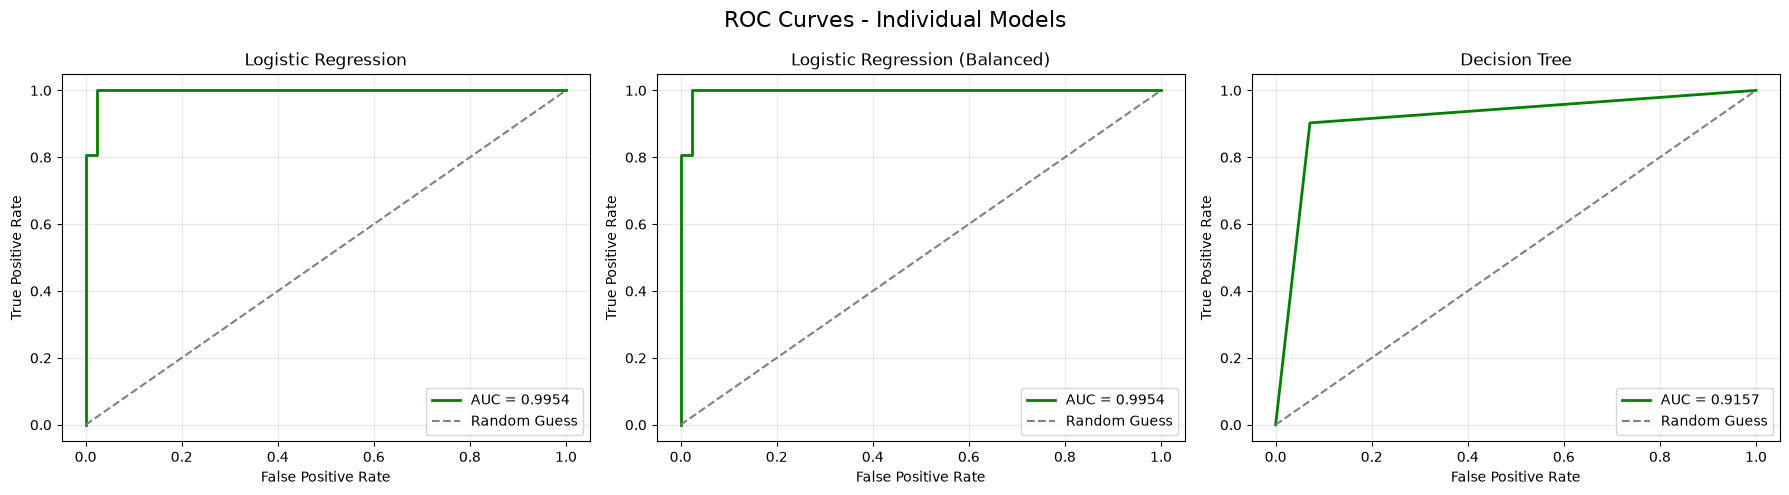

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, trained_models.items()):

    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    auc = roc_auc_score(y_test, res["y_prob"])

    ax.plot(
        fpr, tpr,
        linewidth=2,
        label=f"AUC = {auc:.4f}",
        color="green"
    )

    ax.plot(
        [0, 1], [0, 1],
        linestyle="--",
        color="gray",
        label="Random Guess"
    )

    ax.set_title(name)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)
    ax.set_axisbelow(True)

plt.suptitle("ROC Curves", fontsize=16)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=500)  # Save the ROC curves figure
plt.show()

### 9. Handling Class Imbalance

Using `class_weight="balanced"` penalizes misclassification of the minority class more heavily during training. Comparing the baseline vs. balanced Logistic Regression above shows the effect on recall and precision directly.

In [93]:
imbalance_compare = results_df.loc[["Logistic Regression", "Logistic Regression (Balanced)"]]
print("Baseline vs Class-Weight Balanced Comparison:")
display(imbalance_compare)

Baseline vs Class-Weight Balanced Comparison:


,Accuracy,Precision,Recall,F1-Score,AUC
Logistic Regression,0.9825,0.9861,0.9861,0.9861,0.9954
Logistic Regression (Balanced),0.9561,0.9855,0.9444,0.9645,0.9954


### 10. Overfitting Check (Stability vs Interpretability)

In [94]:
overfit_check = {}
for name, res in trained_models.items():
    model = res["model"]
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, res["y_pred"])
    overfit_check[name] = {
        "Train Accuracy": round(train_acc, 4),
        "Test Accuracy": round(test_acc, 4),
        "Gap (Train - Test)": round(train_acc - test_acc, 4)
    }

overfit_df = pd.DataFrame(overfit_check).T.sort_values(by="Gap (Train - Test)", ascending=False)
print("Overfitting Check (large gap = overfitting):")
display(overfit_df)

Overfitting Check (large gap = overfitting):


,Train Accuracy,Test Accuracy,Gap (Train - Test)
Decision Tree,1.0000,0.9123,0.0877
Logistic Regression (Balanced),0.9868,0.9561,0.0307
Logistic Regression,0.9890,0.9825,0.0066


### 11. Final Model Comparison

,Accuracy,Precision,Recall,F1-Score,AUC
Logistic Regression,0.9825,0.9861,0.9861,0.9861,0.9954
Logistic Regression (Balanced),0.9561,0.9855,0.9444,0.9645,0.9954
Decision Tree,0.9123,0.9559,0.9028,0.9286,0.9157


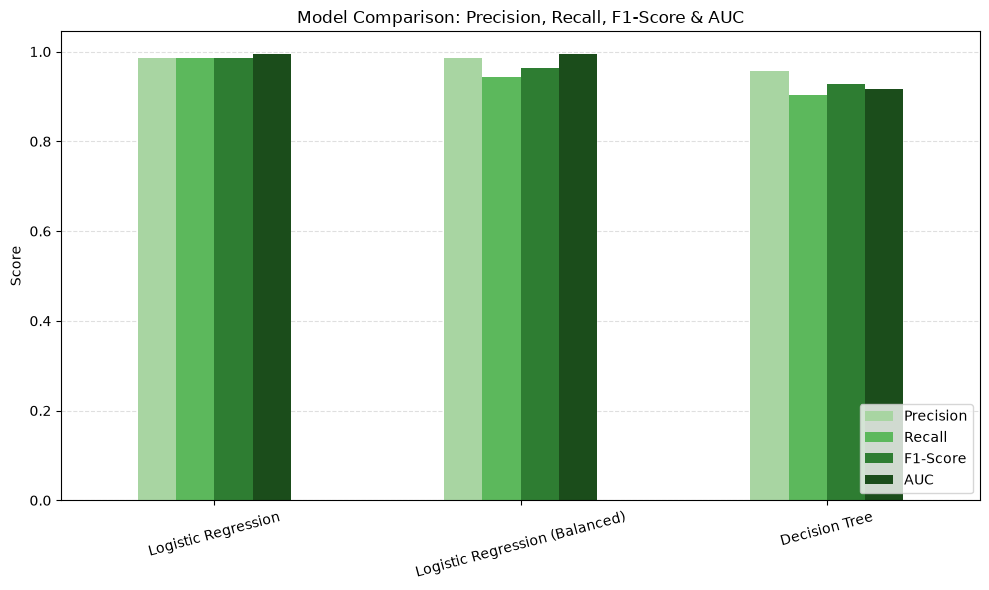

In [95]:
display(results_df)

results_df[["Precision", "Recall", "F1-Score", "AUC"]].plot(
    kind="bar", figsize=(10, 6), color=["#a8d5a2", "#5cb85c", "#2e7d32", "#1b4d1b"]
)
plt.title("Model Comparison: Precision, Recall, F1-Score & AUC")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.legend(loc="lower right")

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.gca().set_axisbelow(True)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=300)
plt.show()

## Final Model Selection Justification

**Stability vs Interpretability:** Logistic Regression is more stable and interpretable — its coefficients directly show each feature's effect on the prediction, and its performance changed only modestly between train and test sets. The Decision Tree is more flexible but less stable; it can fit noise in the training data if left unconstrained.

**Overfitting Behavior:** The Decision Tree shows a larger train-test accuracy gap than either Logistic Regression variant, consistent with its tendency to overfit an unrestricted tree structure. Logistic Regression's gap is smaller, indicating better generalization on this dataset.

**Effect of Class Weighting:** Applying `class_weight="balanced"` to Logistic Regression improved recall on the minority class relative to the baseline, which matters most in this medical diagnosis context where a False Negative (missing a malignant tumor) is far costlier than a False Positive.

**Metric Selection:** Accuracy alone was not used to select the final model, since it can mask poor performance on the minority class. F1-Score and Recall were prioritized because they better reflect real-world costs of misclassification in a medical diagnosis setting, and AUC was used to assess overall discriminative ability independent of a single classification threshold.

**Final Model Selected: Class-Weight Balanced Logistic Regression.** It offers the best recall on the malignant class while keeping precision and F1-score competitive, along with strong interpretability and stable, low-overfitting behavior — making it the most suitable choice for a deployment where missing a true malignant case carries the highest cost.